In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
from pathlib import Path
import pandas as pd
import os

# Caminhos
PROCESSED_DIR = Path("../../data/Airbnb Prices in European Cities/processed/")

train_path = PROCESSED_DIR / "global_treino.csv"
test_path = PROCESSED_DIR / "global_teste.csv"


df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)


print(df_train.shape, df_test.shape)

(10260, 14) (2566, 14)


In [4]:
TARGET = "realSum"


X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]


X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

In [5]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.model_selection import KFold

def analise_hiperparametros(features, target):

    search_space = {
        "n_estimators": Integer(400, 800),
        "learning_rate": Real(0.05, 0.1, prior="log-uniform"),
        "max_depth": Integer(3, 8),
        "min_child_weight": Integer(1, 8),
        "subsample": Real(0.7, 1.0),
        "colsample_bytree": Real(0.7, 1.0),
        "gamma": Real(0, 1),
        "reg_alpha": Real(0, 1),
        "reg_lambda": Real(0.1, 10)
    }

    opt = BayesSearchCV(
        XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ),
        search_spaces=search_space,
        n_iter=40,         
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        scoring="r2",
        n_jobs=-1,
        verbose=1,
        random_state=42,
        return_train_score= True
    )

    opt.fit(features, target)
    return opt


In [6]:
grid = analise_hiperparametros(X_train, y_train)

best_model = grid.best_estimator_

print("Melhores hiperparâmetros:")
print(grid.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [7]:
y_pred = best_model.predict(X_test)

In [8]:
results = grid.cv_results_
fold = 1
for std in results["std_test_score"]:
    print(f'Fold {fold} , std: {std}')
    fold += 1

Fold 1 , std: 0.016190703596241487
Fold 2 , std: 0.015456120534872907
Fold 3 , std: 0.014454262332937626
Fold 4 , std: 0.019406437665335577
Fold 5 , std: 0.018363964121436496
Fold 6 , std: 0.014466108546367356
Fold 7 , std: 0.015055967930791074
Fold 8 , std: 0.014970825282754018
Fold 9 , std: 0.017723397066270775
Fold 10 , std: 0.015699807245864693
Fold 11 , std: 0.020755354304250146
Fold 12 , std: 0.010477949832491522
Fold 13 , std: 0.01825697363289304
Fold 14 , std: 0.01678574588433568
Fold 15 , std: 0.019045276386465807
Fold 16 , std: 0.020306678905951895
Fold 17 , std: 0.020383647054263977
Fold 18 , std: 0.019479027118470493
Fold 19 , std: 0.012975203209074157
Fold 20 , std: 0.018032469078320155
Fold 21 , std: 0.012493093976364411
Fold 22 , std: 0.013458191531384866
Fold 23 , std: 0.01031177034696843
Fold 24 , std: 0.012940134281593811
Fold 25 , std: 0.011241955232308858
Fold 26 , std: 0.01034922060306468
Fold 27 , std: 0.021672022349445548
Fold 28 , std: 0.016496060502135815
Fold 

In [9]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MSE : 0.0025
RMSE: 0.0504
R²  : 0.8160


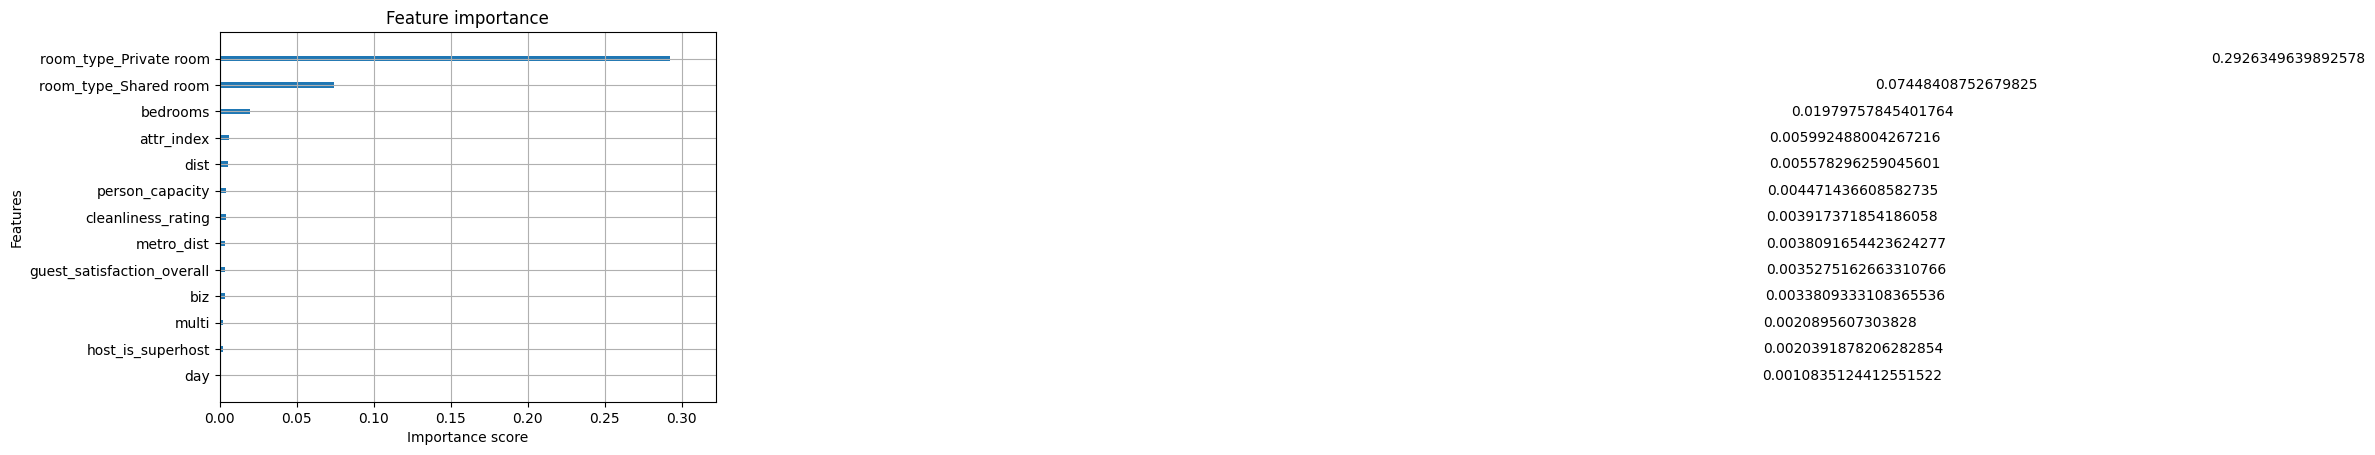

In [10]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

#usa o plot_importance nativo do xgboost
#não achei muito organizado

plot_importance(best_model, importance_type="gain", max_num_features=15)
plt.show()

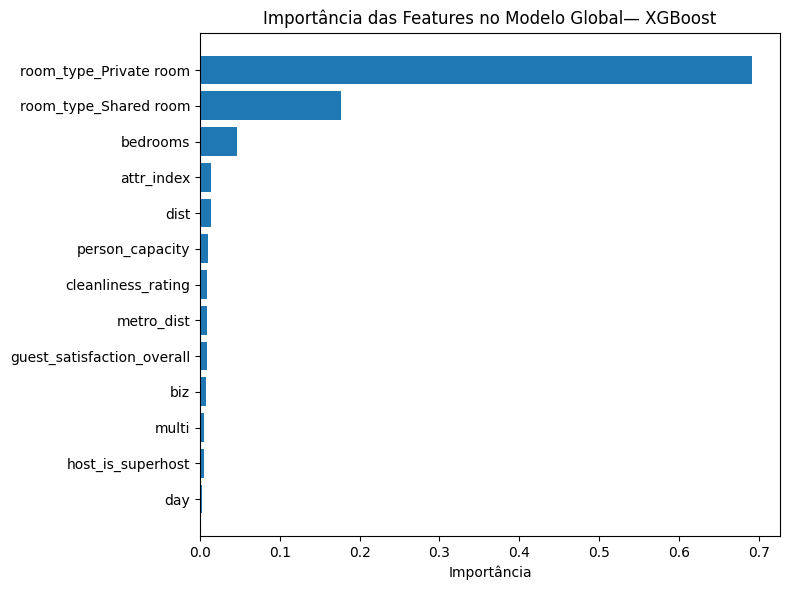

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

#mais organizado

importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importances.index[-15:], importances.values[-15:])
plt.xlabel("Importância")
plt.title("Importância das Features no Modelo Global— XGBoost")
plt.tight_layout()
plt.show()


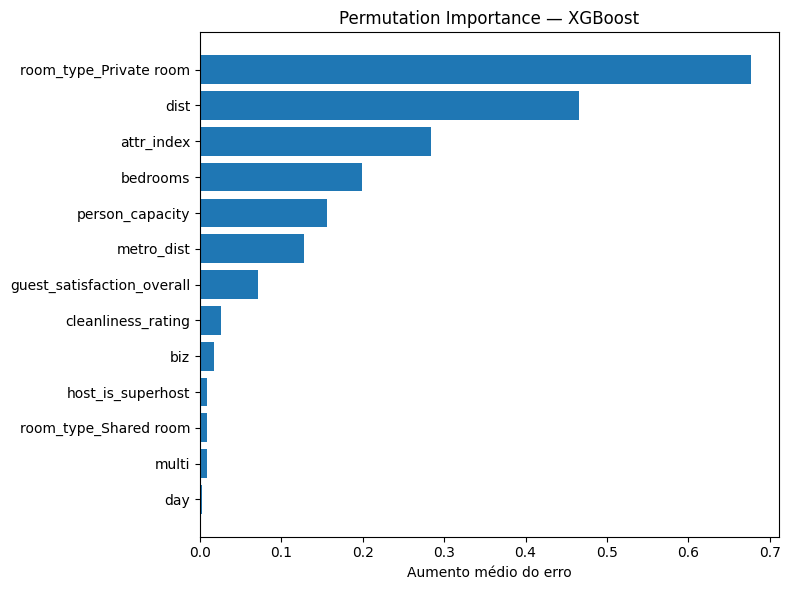

In [12]:
from sklearn.inspection import permutation_importance

#usando permutation importance que embaralha os valores das features e avalia quais criam erros maiores
#erro maior quer dizer maior importancia da feature

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(perm_importance.index[-15:], perm_importance.values[-15:])
plt.xlabel("Aumento médio do erro")
plt.title("Permutation Importance — XGBoost")
plt.tight_layout()
plt.show()


“Qual tipo de acomodação carrega mais informação preditiva para o preço: private ou shared?”

In [14]:
print(X_train.columns.tolist())


['person_capacity', 'host_is_superhost', 'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'attr_index', 'day', 'room_type_Private room', 'room_type_Shared room']


In [16]:
# MODELO 2 — SÓ PRIVATE
X_train_private = X_train.drop(columns=["room_type_Shared room"])
X_test_private  = X_test.drop(columns=["room_type_Shared room"])

grid_private = analise_hiperparametros(X_train_private, y_train)
best_private = grid_private.best_estimator_

y_pred = best_private.predict(X_test_private)
r2_private = r2_score(y_test, y_pred)

resultados = []

resultados.append({
    "modelo": "Só private (vs resto)",
    "R2": r2
})

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [17]:
# MODELO 3 — SÓ SHARED
X_train_shared = X_train.drop(columns=["room_type_Private room"])
X_test_shared  = X_test.drop(columns=["room_type_Private room"])

grid_shared = analise_hiperparametros(X_train_shared, y_train)
best_shared = grid_shared.best_estimator_

y_pred = best_shared.predict(X_test_shared)
r2_shared = r2_score(y_test, y_pred)

resultados.append({
    "modelo": "Só shared (vs resto)",
    "R2": r2
})


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [18]:
# MODELO 4 — SEM TIPO DE QUARTO
room_cols = [
    "room_type_Private room",
    "room_type_Shared room"
]

X_train_no_room = X_train.drop(columns=room_cols)
X_test_no_room  = X_test.drop(columns=room_cols)

grid_no_room = analise_hiperparametros(X_train_no_room, y_train)
best_no_room = grid_no_room.best_estimator_

y_pred = best_no_room.predict(X_test_no_room)
r2_no_room = r2_score(y_test, y_pred)


resultados.append({
    "modelo": "Sem tipo de quarto",
    "R2": r2
})

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [20]:
import pandas as pd

resultados_df = pd.DataFrame({
    "Modelo": [
        "Só Private",
        "Só Shared",
        "Sem tipo de quarto"
    ],
    "R²": [
        r2_private,
        r2_shared,
        r2_no_room
    ]
})

print(resultados_df)


               Modelo        R²
0          Só Private  0.805636
1           Só Shared  0.758949
2  Sem tipo de quarto  0.766535
